In [1]:
import pandas as pd
import matplotlib.pyplot as plt
bmms = pd.read_excel("BMMS_overview.xlsx")
df = pd.read_csv("_roads3.csv")

In [3]:
import pandas as pd
import numpy as np

def to_num(series):
    s = series.astype(str).str.strip().str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

# BMMS: bridge if contains "bridge" but NOT "culvert"
def bmms_is_bridge(x: str) -> bool:
    s = str(x).strip().lower()
    return ("bridge" in s) and ("culvert" not in s)

# ROADS: pure bridge if tokens split by "/" are all exactly "bridge"
def roads_is_pure_bridge(x: str) -> bool:
    s = str(x).strip()
    parts = [p.strip().lower() for p in s.split("/")]
    return (len(parts) >= 1) and all(p == "bridge" for p in parts)

# ============================
# 1) FILTER N1 + NUMERIC CHAINAGE
# ============================
bmms = bmms.copy()
df = df.copy()

bmms["road"] = bmms["road"].astype(str).str.strip().str.upper()
df["road"]   = df["road"].astype(str).str.strip().str.upper()

bmms_n1 = bmms[bmms["road"] == "N1"].copy()
roads_n1 = df[df["road"] == "N1"].copy()

bmms_n1["chainage_num"] = to_num(bmms_n1["chainage"])
roads_n1["chainage_num"] = to_num(roads_n1["chainage"])

print("BMMS N1:", bmms_n1.shape, "chainage NaN:", bmms_n1["chainage_num"].isna().sum())
print("roads N1:", roads_n1.shape, "chainage NaN:", roads_n1["chainage_num"].isna().sum())

# ============================
# 2) BMMS: BRIDGES ONLY + DEDUPE TO 1 ROW PER BRIDGE
# ============================
bmms_n1["type"] = bmms_n1["type"].astype(str)
bmms_bridge = bmms_n1[bmms_n1["type"].apply(bmms_is_bridge)].copy()

print("\nBMMS bridge rows (raw):", bmms_bridge.shape)
print("BMMS bridge type counts:\n", bmms_bridge["type"].value_counts())

# dedupe by rounded chainage (tune rounding if needed)
bmms_bridge["chainage_round"] = bmms_bridge["chainage_num"].round(3)

# Prefer by EstimatedLoc if available
if "EstimatedLoc" in bmms_bridge.columns:
    priority = {"bcs1": 0, "road_precise": 1, "road_interpolate": 2}
    bmms_bridge["loc_rank"] = bmms_bridge["EstimatedLoc"].map(priority).fillna(99)
    bmms_bridge_unique = (
        bmms_bridge
        .sort_values(["road", "chainage_round", "loc_rank"])
        .drop_duplicates(["road", "chainage_round"], keep="first")
        .reset_index(drop=True)
        .drop(columns=["loc_rank"])
    )
else:
    bmms_bridge_unique = (
        bmms_bridge
        .sort_values(["road", "chainage_round"])
        .drop_duplicates(["road", "chainage_round"], keep="first")
        .reset_index(drop=True)
    )

print("\nBMMS bridges unique:", bmms_bridge_unique.shape)

# ============================
# 3) ROADS: DEFINE MESA BRIDGES PROPERLY
# ============================
roads_n1["type"] = roads_n1["type"].astype(str)

# Recommended: keep only "pure bridge" (Bridge, Bridge / Bridge, etc.)
roads_n1["model_type"] = np.where(roads_n1["type"].apply(roads_is_pure_bridge), "bridge", "link")

print("\nMesa model_type counts (before building mesa_df):")
print(roads_n1["model_type"].value_counts())

# ============================
# 4) SORT + COMPUTE SEGMENT LENGTH (meters)
# ============================
roads_n1 = roads_n1.sort_values("chainage_num").reset_index(drop=True)
roads_n1["segment_length_m"] = roads_n1["chainage_num"].diff().shift(-1) * 1000
roads_n1["segment_length_m"] = roads_n1["segment_length_m"].fillna(0).clip(lower=0)

# ============================
# 5) BUILD mesa_df + EXPORT n1.csv (KEEP type!)
# ============================
uid = 1000000
rows = []

# Source
rows.append({
    "road": "N1",
    "id": uid,
    "model_type": "source",
    "type": "source",
    "name": "source",
    "lat": float(roads_n1.iloc[0]["lat"]),
    "lon": float(roads_n1.iloc[0]["lon"]),
    "length": 0.0,
    "chainage": 0.0,
    "condition": ""
})
uid += 1

link_i = 0
bridge_i = 0

for _, r in roads_n1.iterrows():
    mt = r["model_type"]
    if mt == "link":
        link_i += 1
        nm = f"link {link_i}"
    else:
        bridge_i += 1
        nm = f"bridge {bridge_i}"

    rows.append({
        "road": "N1",
        "id": uid,
        "model_type": mt,
        "type": r["type"],
        "name": nm,
        "lat": float(r["lat"]),
        "lon": float(r["lon"]),
        "length": float(r["segment_length_m"]),
        "chainage": float(r["chainage_num"]),
        "condition": ""
    })
    uid += 1

# Sink
rows.append({
    "road": "N1",
    "id": uid,
    "model_type": "sink",
    "type": "sink",
    "name": "sink",
    "lat": float(roads_n1.iloc[-1]["lat"]),
    "lon": float(roads_n1.iloc[-1]["lon"]),
    "length": 0.0,
    "chainage": float(roads_n1.iloc[-1]["chainage_num"]),
    "condition": ""
})

mesa_df = pd.DataFrame(rows)
cols = ["road","id","model_type","type","name","lat","lon","length","chainage","condition"]
mesa_df = mesa_df[cols]

mesa_df.to_csv("n1.csv", index=False)
print("\nSaved n1.csv")
print("Mesa shape:", mesa_df.shape)
print("Mesa bridge count:", (mesa_df["model_type"]=="bridge").sum())

# ============================
# 6) MERGE BMMS CONDITION ONTO MESA BRIDGES (CHAINAGE-NEAREST WITH THRESHOLD)
# ============================
mesa_df["chainage_num"] = to_num(mesa_df["chainage"])

bmms_sorted = bmms_bridge_unique.sort_values("chainage_num").reset_index(drop=True)

THR_KM = 0.5  # accept match only if within 0.5 km
cond_out = np.array([""] * len(mesa_df), dtype=object)
gap_out  = np.full(len(mesa_df), np.nan)

bridge_mask = mesa_df["model_type"] == "bridge"

for idx in mesa_df[bridge_mask].index:
    c = mesa_df.loc[idx, "chainage_num"]
    if pd.isna(c):
        continue
    diffs = (bmms_sorted["chainage_num"] - c).abs()
    j = diffs.idxmin()
    gap = float(diffs.loc[j])
    if gap <= THR_KM:
        cond_out[idx] = str(bmms_sorted.loc[j, "condition"])
        gap_out[idx]  = gap

mesa_df["condition"] = cond_out
mesa_df["chainage_gap_km"] = gap_out

filled = ((mesa_df["model_type"]=="bridge") & (mesa_df["condition"]!="")).sum()
total_br = (mesa_df["model_type"]=="bridge").sum()

print("\nFilled bridge conditions:", filled, "/", total_br)
print("Max gap among filled (km):", np.nanmax(mesa_df.loc[mesa_df["condition"]!="","chainage_gap_km"]))

# Save merged
out_cols = ["road","id","model_type","type","name","lat","lon","length","chainage","condition","chainage_gap_km"]
mesa_df[out_cols].to_csv("n1_with_condition.csv", index=False)
print("Saved n1_with_condition.csv")

# ============================
# 7) DIAGNOSTICS: SEE WHAT DID NOT MATCH
# ============================
unmatched = mesa_df[(mesa_df["model_type"]=="bridge") & (mesa_df["condition"]=="")].copy()
print("\nUnmatched bridges:", len(unmatched))
print("Unmatched chainage range:", unmatched["chainage_num"].min(), "to", unmatched["chainage_num"].max())

# Worst (closest) gaps even when not accepted (help decide THR_KM)
# compute nearest gap for unmatched to see if threshold is too strict
nearest_gaps = []
for c in unmatched["chainage_num"].dropna().values:
    diffs = (bmms_sorted["chainage_num"] - c).abs()
    nearest_gaps.append(float(diffs.min()))
if len(nearest_gaps):
    print("Nearest-gap stats for unmatched (km):",
          pd.Series(nearest_gaps).describe())

BMMS N1: (787, 21) chainage NaN: 0
roads N1: (1339, 9) chainage NaN: 0

BMMS bridge rows (raw): (308, 21)
BMMS bridge type counts:
 type
RCC Girder Bridge    203
PC Girder Bridge     101
RCC Bridge             4
Name: count, dtype: int64

BMMS bridges unique: (158, 22)

Mesa model_type counts (before building mesa_df):
model_type
link      1023
bridge     316
Name: count, dtype: int64

Saved n1.csv
Mesa shape: (1341, 10)
Mesa bridge count: 316

Filled bridge conditions: 180 / 316
Max gap among filled (km): 0.4890000000000043
Saved n1_with_condition.csv

Unmatched bridges: 136
Unmatched chainage range: 8.011 to 461.946
Nearest-gap stats for unmatched (km): count    136.000000
mean       3.244574
std        4.339458
min        0.502000
25%        0.739500
50%        1.097000
75%        3.883250
max       22.228000
dtype: float64


In [4]:
df.head(10)

,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,0.814,LRPSa,23.702917,90.450417,NaN,Culvert,Box Culvert
2,N1,0.822,LRPSb,23.702778,90.450472,NaN,CrossRoad,Intersection with Z1101
3,N1,1.000,LRP001,23.702139,90.451972,NaN,KmPost,Km post missing
4,N1,2.000,LRP002,23.697889,90.460583,NaN,KmPost,Km post missing
5,N1,2.130,LRP002a,23.697361,90.461667,NaN,Culvert,Box culvert
6,N1,3.000,LRP003,23.693833,90.469138,NaN,KmPost,Km post missing
7,N1,4.000,LRP004,23.693611,90.478777,NaN,KmPost,Km post missing
8,N1,4.175,LRP004a,23.693805,90.480527,NaN,"SideRoad,Right",Road to Narayanganj(R111)
9,N1,5.000,LRP005,23.694750,90.488500,NaN,KmPost,Km post missing


In [5]:
mesa_br = mesa_df[mesa_df["model_type"] == "bridge"].copy()
mesa_br["chainage_num"] = pd.to_numeric(mesa_br["chainage"], errors="coerce")
mesa_br = mesa_br.sort_values("chainage_num").reset_index()   # keep original row index in 'index'
print("Mesa bridge rows:", len(mesa_br))

Mesa bridge rows: 316


In [6]:
import numpy as np

lat = mesa_br["lat"].to_numpy()
lon = mesa_br["lon"].to_numpy()

lat0 = np.deg2rad(np.nanmean(lat))
scale_lat = 111_000
scale_lon = 111_000 * np.cos(lat0)

N = len(mesa_br)
used = np.zeros(N, dtype=bool)
pairs = []

for i in range(N):
    if used[i]:
        continue

    dlat = (lat - lat[i]) * scale_lat
    dlon = (lon - lon[i]) * scale_lon
    dist = np.sqrt(dlat**2 + dlon**2)

    dist[i] = np.inf
    dist[used] = np.inf

    j = np.argmin(dist)

    pairs.append((i, j))
    used[i] = True
    used[j] = True

print("Pairs formed:", len(pairs))

Pairs formed: 158


In [7]:
rows = []

for k, (i, j) in enumerate(pairs):
    r1 = mesa_br.iloc[i]
    r2 = mesa_br.iloc[j]

    rows.append({
        "pair_id": k,
        "idx0": r1["index"],
        "idx1": r2["index"],
        "chainage_num": np.mean([r1["chainage"], r2["chainage"]]),
        "lat": np.mean([r1["lat"], r2["lat"]]),
        "lon": np.mean([r1["lon"], r2["lon"]]),
    })

mesa_phys = pd.DataFrame(rows)

print("Physical bridges:", len(mesa_phys))

Physical bridges: 158


In [8]:
THR_KM = 3.0

bmms_xy = bmms_bridge_unique[["lat","lon"]].to_numpy()
mesa_xy = mesa_phys[["lat","lon"]].to_numpy()

lat0 = np.deg2rad(np.nanmean(mesa_xy[:,0]))
scale_lat = 111_000
scale_lon = 111_000 * np.cos(lat0)

bmms_lat = bmms_xy[:,0]
bmms_lon = bmms_xy[:,1]

conds = []
gaps = []
matched = []

for i in range(len(mesa_phys)):
    lat_i, lon_i = mesa_xy[i]

    dlat = (bmms_lat - lat_i) * scale_lat
    dlon = (bmms_lon - lon_i) * scale_lon
    dist = np.sqrt(dlat**2 + dlon**2) / 1000  # km

    j = np.argmin(dist)
    best = dist[j]

    if best <= THR_KM:
        conds.append(bmms_bridge_unique.iloc[j]["condition"])
        matched.append(True)
    else:
        conds.append("")
        matched.append(False)

    gaps.append(best)

mesa_phys["bmms_condition"] = conds
mesa_phys["spatial_gap_km"] = gaps
mesa_phys["matched"] = matched

print("Matched physical bridges:", mesa_phys["matched"].sum(), "/", len(mesa_phys))
print(mesa_phys["spatial_gap_km"].describe())

Matched physical bridges: 133 / 158
count    158.000000
mean       1.592235
std        3.125656
min        0.002856
25%        0.030533
50%        0.321247
75%        1.608839
max       20.742449
Name: spatial_gap_km, dtype: float64


In [9]:
mesa_df["condition"] = ""
mesa_df["chainage_gap_km"] = np.nan

for _, r in mesa_phys.iterrows():
    if not r["matched"]:
        continue

    mesa_df.loc[r["idx0"], "condition"] = r["bmms_condition"]
    mesa_df.loc[r["idx1"], "condition"] = r["bmms_condition"]

    mesa_df.loc[r["idx0"], "chainage_gap_km"] = r["spatial_gap_km"]
    mesa_df.loc[r["idx1"], "chainage_gap_km"] = r["spatial_gap_km"]

filled = ((mesa_df["model_type"]=="bridge") & (mesa_df["condition"]!="")).sum()
total = (mesa_df["model_type"]=="bridge").sum()

print("Filled Mesa bridge nodes:", filled, "/", total)

Filled Mesa bridge nodes: 266 / 316


In [10]:
bad = mesa_phys[~mesa_phys["matched"]].copy()
print(bad[["chainage_num","lat","lon","spatial_gap_km"]].head(20))

     chainage_num        lat        lon  spatial_gap_km
31       105.7140  23.335875  91.270180        3.075556
32       107.3260  23.324124  91.279138        4.672113
33       108.5275  23.314847  91.284514        5.834502
34       110.7740  23.296027  91.291514        7.992620
35       116.6195  23.248250  91.309847       13.570729
36       123.7770  23.186652  91.321263       20.336292
37       125.9300  23.168097  91.321360       20.742449
38       136.5335  23.080749  91.354903       10.489839
43       172.9850  22.848486  91.546402        7.754983
45       184.7945  22.752569  91.589416        3.795402
49       209.1910  22.557153  91.688111        3.103334
64       236.9940  22.365863  91.811813        4.394736
71       256.6905  22.298069  91.921139        4.435723
82       290.5155  22.099110  92.087375        3.589060
90       315.2900  21.905583  92.064069        5.096036
93       329.3425  21.787111  92.079458        4.343989
95       339.6665  21.702194  92.080222        3

In [11]:
mesa_df[mesa_df["model_type"] == "bridge"]

,road,id,model_type,type,name,lat,lon,length,chainage,condition,chainage_num,chainage_gap_km
15,N1,1000015,bridge,Bridge,bridge 1,23.702111,90.515778,418.0,8.011,C,8.011,0.200139
16,N1,1000016,bridge,Bridge,bridge 2,23.704583,90.518833,74.0,8.429,C,8.429,0.200139
27,N1,1000027,bridge,Bridge,bridge 3,23.691111,90.544889,26.0,11.745,A,11.745,0.013194
28,N1,1000028,bridge,Bridge,bridge 4,23.691055,90.545139,165.0,11.771,A,11.771,0.013194
37,N1,1000037,bridge,Bridge,bridge 5,23.659111,90.569722,160.0,16.242,B,16.242,0.083492
...,...,...,...,...,...,...,...,...,...,...,...,...
1327,N1,1001327,bridge,Bridge,bridge 312,20.888833,92.298389,258.0,459.130,B,459.130,0.085254
1332,N1,1001332,bridge,Bridge,bridge 313,20.876860,92.297889,43.0,460.589,B,460.589,0.009548
1333,N1,1001333,bridge,Bridge,bridge 314,20.876499,92.297889,794.0,460.632,B,460.632,0.009548
1336,N1,1001336,bridge,Bridge,bridge 315,20.865028,92.298250,42.0,461.904,C,461.904,0.041115


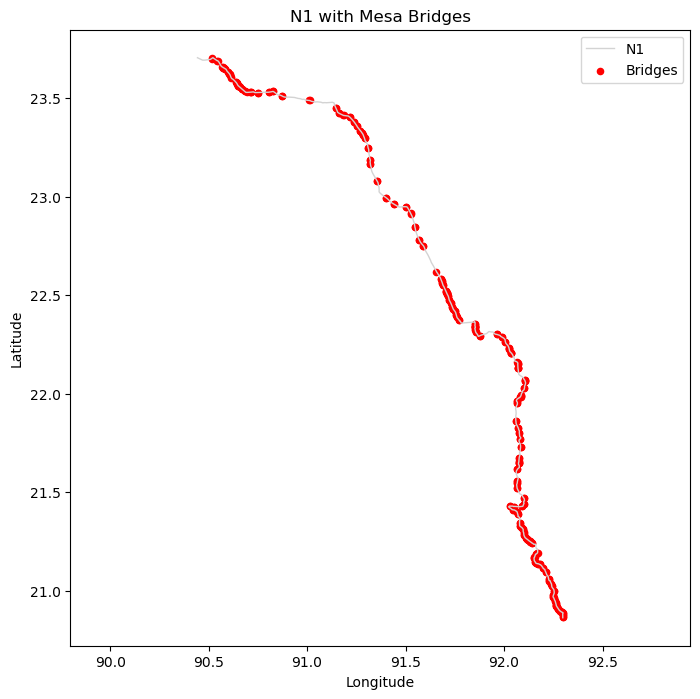

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# Road alignment (all nodes)
plt.plot(mesa_df["lon"], mesa_df["lat"], color="lightgray", linewidth=1, label="N1")

# Bridges only
bridges = mesa_df[mesa_df["model_type"] == "bridge"]

plt.scatter(bridges["lon"], bridges["lat"],
            c="red", s=20, label="Bridges")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("N1 with Mesa Bridges")
plt.legend()
plt.axis("equal")
plt.show()

In [13]:
mesa_df.to_csv("n1_mesa_with_condition.csv", index=False)

In [14]:
# Filter: alleen links en bridges
filtered_df = mesa_df[mesa_df["model_type"].isin(["link", "bridge"])].copy()

# Kolommen die we willen behouden
cols = ["road", "id", "model_type", "name", "lat", "lon", "length"]

# Nieuwe dataframe maken met alleen gewenste kolommen
new_df = filtered_df[cols].copy()

# Condition kolom toevoegen (als hij bestaat, anders leeg laten)
if "condition" in filtered_df.columns:
    new_df["condition"] = filtered_df["condition"]
else:
    new_df["condition"] = None

# Exporteren naar nieuwe CSV
new_df.to_csv("n1_links_bridges_with_condition.csv", index=False)

print("CSV succesvol aangemaakt: n1_links_bridges_with_condition.csv")

CSV succesvol aangemaakt: n1_links_bridges_with_condition.csv
